#   Forecasting de Demanda Eléctrica en España
## Análisis de Series Temporales con Machine Learning y Variables Meteorológicas

---

###   Descripción del Proyecto

Este proyecto tiene como objetivo **predecir la demanda eléctrica en España** utilizando modelos estadísticos (SARIMA) y modelos de Machine Learning, incorporando **variables meteorológicas y energéticas** como factores explicativos clave.

**Dataset:** [Energy Consumption, Generation, Prices and Weather - Spain (Kaggle)](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)

**Contexto:**
Según un paper de 2019, el forecasting en mercados energéticos es una de las áreas de mayor impacto del Machine/Deep Learning para la transición hacia una infraestructura eléctrica basada en renovables.

**Contenido del dataset:**
- **4 años de datos horarios** (2015-2018) 
- Consumo eléctrico real y forecast del TSO
- **Generación por fuente**: solar, eólica, gas, carbón, nuclear, hidráulica
- **Precios spot** y day-ahead
- **Datos meteorológicos** de las 5 ciudades más grandes de España:
  - Madrid, Barcelona, Valencia, Sevilla, Bilbao
  - Variables: temperatura, presión, humedad, velocidad del viento

**Fuentes:**
- ENTSOE (European Network of Transmission System Operators)
- Red Eléctrica de España (REE)
- Open Weather API

---

###   Objetivos Principales

1. **Limpieza y preparación** de datos con tratamiento correcto de valores nulos
2. **Análisis meteorológico**: Demostrar la relación entre clima y demanda eléctrica
3. **Feature Engineering avanzado**: Variables temporales, lags, rolling stats, y **weather features**
4. **Modelado estadístico**: SARIMA con análisis de tendencia, estacionalidad y residuo
5. **Machine Learning**: Random Forest y Gradient Boosting
6. **Análisis técnico**: Medias móviles, Golden Cross y volatilidad
7. **Comparación de modelos** y análisis de feature importance

**Hipótesis clave:**
> Las **variables meteorológicas** (especialmente temperatura) son factores explicativos fundamentales para la demanda eléctrica, junto con la información temporal (lags y estacionalidad).

---

###   Equipo de Trabajo y Responsabilidades

####   **Persona 1: Preparación de Datos y EDA**

**Tareas:**
-   Carga y exploración inicial del dataset
-   Conversión a series temporales (índice datetime)
-   Análisis de valores nulos y estrategia de imputación
-   Análisis exploratorio de demanda eléctrica
-   Análisis meteorológico: correlación clima-demanda
-   Visualizaciones de patrones diarios/semanales/estacionales

**Entregables:**
- Dataset limpio y correctamente indexado
- Informe de calidad de datos
- Gráficos exploratorios de demanda y temperatura

---

####   **Persona 2: Análisis Temporal y Comparación de Modelos**

**Tareas:**

-   **Lags**: 1h, 24h, 168h (capturar autocorrelación)
-   **Descomposición temporal**: tendencia, estacionalidad (period=24), residuo
-   **Test de estacionariedad** (ADF)
-	**ACF**
-   **Modelo SARIMA**: determinación de órdenes (p,d,q)(P,D,Q,s)
-   **Media móvil y Golden Cross** para precios eléctricos
-   **Análisis de volatilidad**

**Entregables:**
- Modelo SARIMA con parámetros justificados
- Análisis de cruces de medias móviles en precios
- Demostración de que temperatura y lags son cruciales

---

####   **Persona 3: Machine Learning**

**Tareas:**
-   **Modelos ML**: Random Forest y Gradient Boosting
-   **Feature importance**: identificar variables más predictivas
-   **Comparación final de modelos**: SARIMA vs RF vs GB
-   Visualizaciones de predicciones vs valores reales

**Entregables:**
- Modelos ML con hiperparámetros optimizados
- Análisis de feature importance
- Tabla comparativa de métricas (RMSE, MAE, MAPE)
- Conclusiones sobre mejor modelo y variables importantes

---

###   Preguntas de Investigación

1. **¿Qué ciudades/mediciones meteorológicas influyen más en la demanda eléctrica?**
2. **¿Podemos predecir 24 horas adelante mejor que el TSO?**
3. **¿Cuál es la relación entre temperatura y demanda?** (hipótesis: forma de U)
4. **¿Qué features son más importantes**: lags, temperatura, hora del día, generación?
5. **¿Qué modelo funciona mejor**: SARIMA, RF o Gradient Boosting?

---

---

##   1. Importación de Librerías

Importamos todas las librerías necesarias para el análisis completo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


---

##   2. Carga y Exploración Inicial del Dataset



In [2]:
# 1. Cargar dataset de energía
df_energy = pd.read_csv('./data/energy_dataset.csv')
print(f"Energy dataset: {df_energy.shape[0]:,} filas × {df_energy.shape[1]} columnas")

# 2. Cargar dataset de clima 
df_weather = pd.read_csv('./data/weather_features.csv')
print(f"Weather dataset: {df_weather.shape[0]:,} filas × {df_weather.shape[1]} columnas")

print("\n" + "=" * 80)
print("ESTRUCTURA DE LOS DATASETS:")
print("=" * 80)

print("\nEnergy Dataset:")
print(df_energy.info())

print("\nWeather Dataset:")
print(df_weather.info())


Energy dataset: 35,064 filas × 29 columnas
Weather dataset: 178,396 filas × 17 columnas

ESTRUCTURA DE LOS DATASETS:

Energy Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation f

---

## 2b. Separación de Columnas de Forecast (Comparación con TSO)

### Objetivo Principal

El propósito de este notebook es **desarrollar nuestro propio pronóstico de demanda eléctrica** utilizando modelos estadísticos (SARIMA) y Machine Learning. Las columnas de forecast del TSO las utilizaremos como **referencia de comparación** para comparar nuestra previsión con la oficial de red electrica.

### Posible Data Leakage

Las columnas de **forecast del TSO** (pronóstico oficial del operador del sistema) representan una **potencial fuente de data leakage**:

- Si usamos estas columnas para entrenar nuestro modelo, estaríamos utilizando información que **no estaría disponible en un escenario real de predicción en tiempo real**.
- Esto podría inflar artificialmente la precisión de nuestro modelo.

### Estrategia: Separar para Comparación Limpia

**Acción:** Extraer columnas de forecast a dataset separado **ANTES del merge**, para:
1. ✓ Entrenar nuestros modelos **sin estas columnas** (pronóstico limpio)
2. ✓ **Comparar nuestras predicciones** con el pronóstico oficial del TSO
3. ✓ Responder: **¿Predecimos mejor o peor que el TSO?**

In [3]:
# Identificar y separar columnas de forecast (TSO) antes del merge
forecast_cols = [col for col in df_energy.columns if 'forecast' in col.lower() or 'ahead' in col.lower()]

print(f"Columnas de forecast encontradas: {len(forecast_cols)}")
print("Columnas identificadas:")
for col in forecast_cols:
    print(f"  - {col}")

# 1. Crear dataset separado con forecast (para comparación posterior)
df_forecast_tso = df_energy[['time'] + forecast_cols].copy()

print(f"\nDataset de forecast creado: {df_forecast_tso.shape}")
print(f"Rango: {df_forecast_tso['time'].min()} → {df_forecast_tso['time'].max()}")

# 2. Eliminar columnas de forecast del dataset principal (evitar data leakage)
df_energy = df_energy.drop(columns=forecast_cols)

Columnas de forecast encontradas: 5
Columnas identificadas:
  - forecast solar day ahead
  - forecast wind offshore eday ahead
  - forecast wind onshore day ahead
  - total load forecast
  - price day ahead

Dataset de forecast creado: (35064, 6)
Rango: 2015-01-01 00:00:00+01:00 → 2018-12-31 23:00:00+01:00


In [4]:
# Convertir 'time' a datetime en ambos (con utc=True para manejar el cambio de horario verano/invierno)
df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True)
df_weather['time'] = pd.to_datetime(df_weather['dt_iso'], utc=True)
df_weather.drop(columns='dt_iso', inplace=True)

# Limpiar nombres de ciudades (Barcelona tiene un espacio inicial en el dataset original)
df_weather['city_name'] = df_weather['city_name'].str.strip()

# Pivotar df_weather: cada ciudad pasa a ser columnas separadas
# Solo columnas numéricas: temp, humidity, wind_speed, pressure, etc.
weather_num_cols = df_weather.select_dtypes(include=[np.number]).columns.tolist()

df_weather_pivot = df_weather.pivot_table(
    index='time',
    columns='city_name',
    values=weather_num_cols,
    aggfunc='mean'  # por si hubiera duplicados en el mismo timestamp
)

# Aplanar MultiIndex: (variable, ciudad) → variable_Ciudad
df_weather_pivot.columns = [f"{var}_{city}" for var, city in df_weather_pivot.columns]
df_weather_pivot = df_weather_pivot.reset_index()

# Merge por 'time' (inner join: solo fechas comunes)
df = pd.merge(df_energy, df_weather_pivot, on='time', how='inner')

print(f"Dataset combinado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Rango de fechas: {df['time'].min()} → {df['time'].max()}")
print(f"Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

cities = ['Valencia', 'Madrid', 'Bilbao', 'Barcelona', 'Seville']
weather_cols_created = sorted(col for col in df.columns if any(city in col for city in cities))
print(f"\nColumnas meteorológicas creadas ({len(weather_cols_created)}):")
for col in weather_cols_created:
    print(f"  - {col}")


Dataset combinado: 35,064 filas × 84 columnas
Rango de fechas: 2014-12-31 23:00:00+00:00 → 2018-12-31 22:00:00+00:00
Memoria utilizada: 22.47 MB

Columnas meteorológicas creadas (60):
  - clouds_all_Barcelona
  - clouds_all_Bilbao
  - clouds_all_Madrid
  - clouds_all_Seville
  - clouds_all_Valencia
  - humidity_Barcelona
  - humidity_Bilbao
  - humidity_Madrid
  - humidity_Seville
  - humidity_Valencia
  - pressure_Barcelona
  - pressure_Bilbao
  - pressure_Madrid
  - pressure_Seville
  - pressure_Valencia
  - rain_1h_Barcelona
  - rain_1h_Bilbao
  - rain_1h_Madrid
  - rain_1h_Seville
  - rain_1h_Valencia
  - rain_3h_Barcelona
  - rain_3h_Bilbao
  - rain_3h_Madrid
  - rain_3h_Seville
  - rain_3h_Valencia
  - snow_3h_Barcelona
  - snow_3h_Bilbao
  - snow_3h_Madrid
  - snow_3h_Seville
  - snow_3h_Valencia
  - temp_Barcelona
  - temp_Bilbao
  - temp_Madrid
  - temp_Seville
  - temp_Valencia
  - temp_max_Barcelona
  - temp_max_Bilbao
  - temp_max_Madrid
  - temp_max_Seville
  - temp_max_Va

---

## 2c. Eliminación de Columnas Innecesarias

Tras el pivot por ciudad, cada variable meteorológica tiene el formato `variable_Ciudad` (ej: `temp_Madrid`, `humidity_Seville`). Eliminamos las que no aportan valor predictivo:

### Columnas a Eliminar:

1. **`temp_min_*` y `temp_max_*`**  
   - En datos **horarios** no tiene sentido tener temperatura mínima/máxima
   - Estos valores tienen sentido solo en **agregaciones diarias**
   - Mejor usar `temp_*` (temperatura actual por hora)

2. **`weather_id_*`**  
   - Identificador interno de la API de OpenWeather
   - Redundante con las columnas categóricas `weather_main` / `weather_description`
   - No aporta información interpretable

> **Nota:** `weather_icon`, `weather_main` y `weather_description` son columnas de texto y **no se incluyen en el pivot numérico**, por lo que no necesitan tratamiento aquí.


In [5]:
# Tras el pivot las columnas tienen sufijo de ciudad: temp_min_Madrid, weather_id_Seville, etc.
# Eliminamos todas las columnas cuyo nombre empiece por estos prefijos
patterns_to_drop = ['temp_min', 'temp_max', 'weather_id']

cols_to_drop = [col for col in df.columns if any(col.startswith(p + '_') for p in patterns_to_drop)]

print(f"Dataset antes: {df.shape}")
print(f"\nColumnas a eliminar ({len(cols_to_drop)}):")
for col in sorted(cols_to_drop):
    print(f"   - {col}")

df = df.drop(columns=cols_to_drop)

print(f"\nDataset después: {df.shape}")
print(f"Columnas eliminadas: {len(cols_to_drop)}")


Dataset antes: (35064, 84)

Columnas a eliminar (15):
   - temp_max_Barcelona
   - temp_max_Bilbao
   - temp_max_Madrid
   - temp_max_Seville
   - temp_max_Valencia
   - temp_min_Barcelona
   - temp_min_Bilbao
   - temp_min_Madrid
   - temp_min_Seville
   - temp_min_Valencia
   - weather_id_Barcelona
   - weather_id_Bilbao
   - weather_id_Madrid
   - weather_id_Seville
   - weather_id_Valencia

Dataset después: (35064, 69)
Columnas eliminadas: 15


#TODO 

In [6]:

# Ajuste de signo: esta serie representa consumo y debe ser negativa
pumped_storage_col = 'generation hydro pumped storage consumption'
if pumped_storage_col in df.columns:
    df[pumped_storage_col] = -df[pumped_storage_col].abs()
    print(f"✅ {pumped_storage_col} ajustada a valores negativos")

✅ generation hydro pumped storage consumption ajustada a valores negativos


---

##   3. Conversión a Series Temporales



**Fundamental:** Convertir la columna `time` a formato datetime y establecerla como índice para trabajar correctamente con series temporales.

In [7]:
# Establecer como índice
df =df.set_index('time')

# Ordenar cronológicamente
df = df.sort_index()

# Verificar frecuencia
print(f"\nPrimera fecha: {df.index.min()}")
print(f"Última fecha: {df.index.max()}")
print(f"📊 Total observaciones: {len(df):,}")
df.head(3)


Primera fecha: 2014-12-31 23:00:00+00:00
Última fecha: 2018-12-31 22:00:00+00:00
📊 Total observaciones: 35,064


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,wind_deg_Barcelona,wind_deg_Bilbao,wind_deg_Madrid,wind_deg_Seville,wind_deg_Valencia,wind_speed_Barcelona,wind_speed_Bilbao,wind_speed_Madrid,wind_speed_Seville,wind_speed_Valencia
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,58.0,226.0,309.0,21.0,62.0,7.0,0.0,1.0,1.0,1.0
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,58.0,229.0,309.0,21.0,62.0,7.0,0.0,1.0,1.0,1.0
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,48.0,224.0,273.0,27.0,23.0,7.0,1.0,1.0,3.0,0.0


---

## 4. Análisis de Valores Nulos

Identificamos y cuantificamos los valores nulos en el dataset. Es importante distinguir entre **valores 0.0** (generación nula registrada) y **valores NaN** (datos no reportados).

### Columnas con 0.0 (Generación Nula Real)

Estas columnas tienen **toda su serie en 0.0** porque España **no utiliza estas fuentes energéticas**:

1. **`generation fossil oil shale`** (Esquistos bituminosos)  
   España no usa esquistos para generación eléctrica comercial.

2. **`generation fossil peat turb`** (Turba)  
   No hay centrales de turba operativas en España.

3. **`generation geothermal`** (Geotermia)  
   A excepción de pequeños proyectos en Canarias, España no produce electricidad geotérmica a gran escala.

4. **`generation marine`** (Energía marina/undimotriz)  
   Tecnología experimental. No aporta energía significativa a la red nacional.

5. **`generation wind offshore`** (Eólica marina)  
   Durante 2015-2018 (periodo del dataset), la eólica marina era **inexistente** en España.

### Columnas con NaN (Datos No Reportados)

Valores **NaN** significan que el dato **no existe o no se reportó**:

1. **`generation hydro pumped storage aggregated`**  
   Las empresas reportan por separado consumo (bombeo hacia arriba) y generación (turbinado). La columna "agregada" queda vacía porque españa identifica la energía generada en otro concepto (generation hydro water reservoir) y da error la agregación.


### Estrategia de Tratamiento

- **Columnas con todo 0.0**: Eliminar (no aportan variabilidad ni información predictiva)
- **Columnas con NaN puntuales**: Aplicar interpolación temporal o forward/backward fill
- **Columnas con todo NaN**: Eliminar (sin información útil)

In [8]:
# Columnas a eliminar
cols_to_drop = [
    'generation fossil oil shale',    
    'generation fossil coal-derived gas',             
    'generation fossil peat',            
    'generation geothermal',          
    'generation hydro pumped storage aggregated',
    'generation marine',
    'generation wind offshore'

]

# Verificar cuáles existen realmente en el dataset
cols_existing = [col for col in cols_to_drop if col in df.columns]
cols_missing = [col for col in cols_to_drop if col not in df.columns]

print(f"Dataset antes: {df.shape}")
print(f"\nColumnas a eliminar ({len(cols_existing)}):")
for col in cols_existing:
    print(f"   - {col}")

if cols_missing:
    print(f"\n⚠️  Columnas no encontradas ({len(cols_missing)}):")
    for col in cols_missing:
        print(f"   - {col}")

# Eliminar columnas existentes
df = df.drop(columns=cols_existing)

print(f"\nDataset después: {df.shape}")
print(f"Columnas eliminadas: {len(cols_existing)}")

Dataset antes: (35064, 68)

Columnas a eliminar (7):
   - generation fossil oil shale
   - generation fossil coal-derived gas
   - generation fossil peat
   - generation geothermal
   - generation hydro pumped storage aggregated
   - generation marine
   - generation wind offshore

Dataset después: (35064, 61)
Columnas eliminadas: 7


---

## 5. Tratamiento de Valores Faltantes

### Estrategia de Imputación

Basándonos en el análisis anterior, aplicamos diferentes técnicas según el tipo de problema:

1. **Eliminar columnas con todo 0.0**  
   No aportan variabilidad ni información (generación inexistente en España)

2. **Eliminar columnas con >90% de NaN**  
   Información insuficiente para imputación confiable

3. **Interpolación temporal** para valores nulos puntuales  
   Método apropiado para series temporales porque asume cambios graduales entre valores consecutivos

4. **Forward/Backward Fill** como respaldo  
   Para NaN al inicio/final de la serie donde la interpolación no funciona

In [9]:
df_clean = df.copy()

# Método 1: Interpolación lineal (mantiene tendencia temporal)
columnas_numericas = df_clean.select_dtypes(include=[np.number]).columns

for col in columnas_numericas:
    if df_clean[col].isna().sum() > 0:
        antes = df_clean[col].isna().sum()
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')
        despues = df_clean[col].isna().sum()
        print(f"{col}: {antes} → {despues} nulos")
        
df_clean.info()


generation biomass: 19 → 0 nulos
generation fossil brown coal/lignite: 18 → 0 nulos
generation fossil gas: 18 → 0 nulos
generation fossil hard coal: 18 → 0 nulos
generation fossil oil: 19 → 0 nulos
generation hydro pumped storage consumption: 19 → 0 nulos
generation hydro run-of-river and poundage: 19 → 0 nulos
generation hydro water reservoir: 18 → 0 nulos
generation nuclear: 17 → 0 nulos
generation other: 18 → 0 nulos
generation other renewable: 18 → 0 nulos
generation solar: 18 → 0 nulos
generation waste: 19 → 0 nulos
generation wind onshore: 18 → 0 nulos
total load actual: 36 → 0 nulos
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Data columns (total 61 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           35064 non-null  float64
 1   generation fossil br

---

##  6. Análisis Meteorológico



Las **variables meteorológicas son fundamentales** para explicar y predecir la demanda eléctrica. Vamos a demostrar la relación entre **temperatura y demanda**.

---

##   7. Feature Engineering Completo



El **feature engineering es CRÍTICO** para el éxito de los modelos ML. Crearemos:
1. Features temporales (hora, día, mes)
2. Lags (autocorrelación)
3. Rolling statistics (tendenciaslocales)
4. **Weather features** (lags y rolling de temperatura)  
5. Variables energéticas (renovables vs fósiles)


##   7. Feature Engineering - Parte A: Variables Temporales



La creación de features temporales es **fundamental** para capturar patrones diarios, semanales y estacionales en la demanda eléctrica.

**Features cíclicas:** Las transformaciones sin/cos permiten que los modelos ML entiendan que la hora 23 está cerca de la hora 0.

---

##   8. Feature Engineering - Parte B: Lags (Autocorrelación)



Los **lags** capturan la autocorrelación temporal: el valor actual depende de valores pasados.

**Lags clave:**
- **lag_1**: Valor hace 1 hora
- **lag_24**: Valor hace 24 horas (ayer misma hora)
- **lag_168**: Valor hace 168 horas (semana pasada misma hora)

---

##   9. Feature Engineering - Parte C: Rolling Statistics



Las **rolling statistics** (estadísticas móviles) capturan tendencias y volatilidad reciente.

**Ventanas importantes:**
- **24 horas**: Captura tendencia/volatilidad del último día
- **168 horas**: Captura tendencia/volatilidad de la última semana

---

##   10. Feature Engineering - Parte D: **Weather Features** 




Las **weather features son FUNDAMENTALES** para predecir demanda eléctrica. La temperatura afecta directamente el consumo (calefacción en invierno, aire acondicionado en verano).

**Features meteorológicas clave:**
- Lags de temperatura (temp_lag24, temp_lag168)
- Rolling statistics de temperatura
- Interacciones con hora del día

---

##   11. Feature Engineering - Parte E: Variables Energéticas



Creamos agregaciones de las fuentes de generación eléctrica para simplificar el análisis.

---

##  12. Descomposición Temporal (Tendencia, Estacionalidad, Residuo)



La descomposición temporal permite separar la serie en:
- **Tendencia**: Patrón de largo plazo
- **Estacionalidad**: Patrón repetitivo (diario/semanal)
- **Residuo**: Variación aleatoria

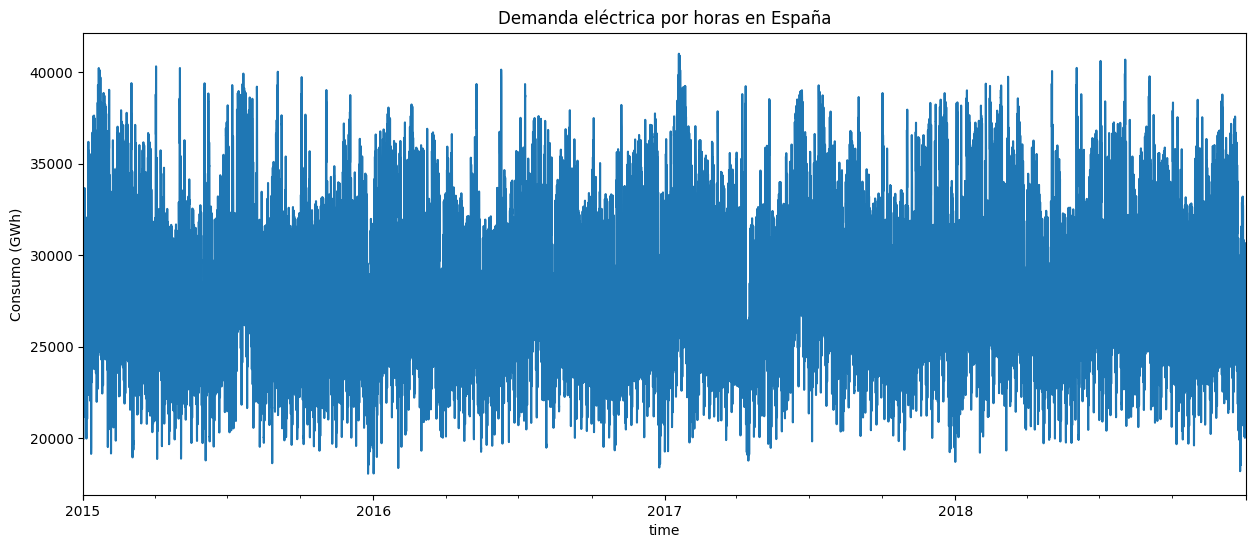

In [10]:
plt.figure(figsize=(15, 6))
df_clean['total load actual'].plot(title='Demanda eléctrica por horas en España')
plt.ylabel('Consumo (GWh)')
plt.show()

Los datos diarios son muy ruidosos. Se remuestrean los datos a una frecuencia **diaria ('D')**, **semanal ('W')** y **mensual ('M')**. Para cada una, grafica el consumo medio.

C:\Users\paros\AppData\Local\Temp\ipykernel_633536\3000029995.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensual = df_clean['total load actual'].resample('M').mean()


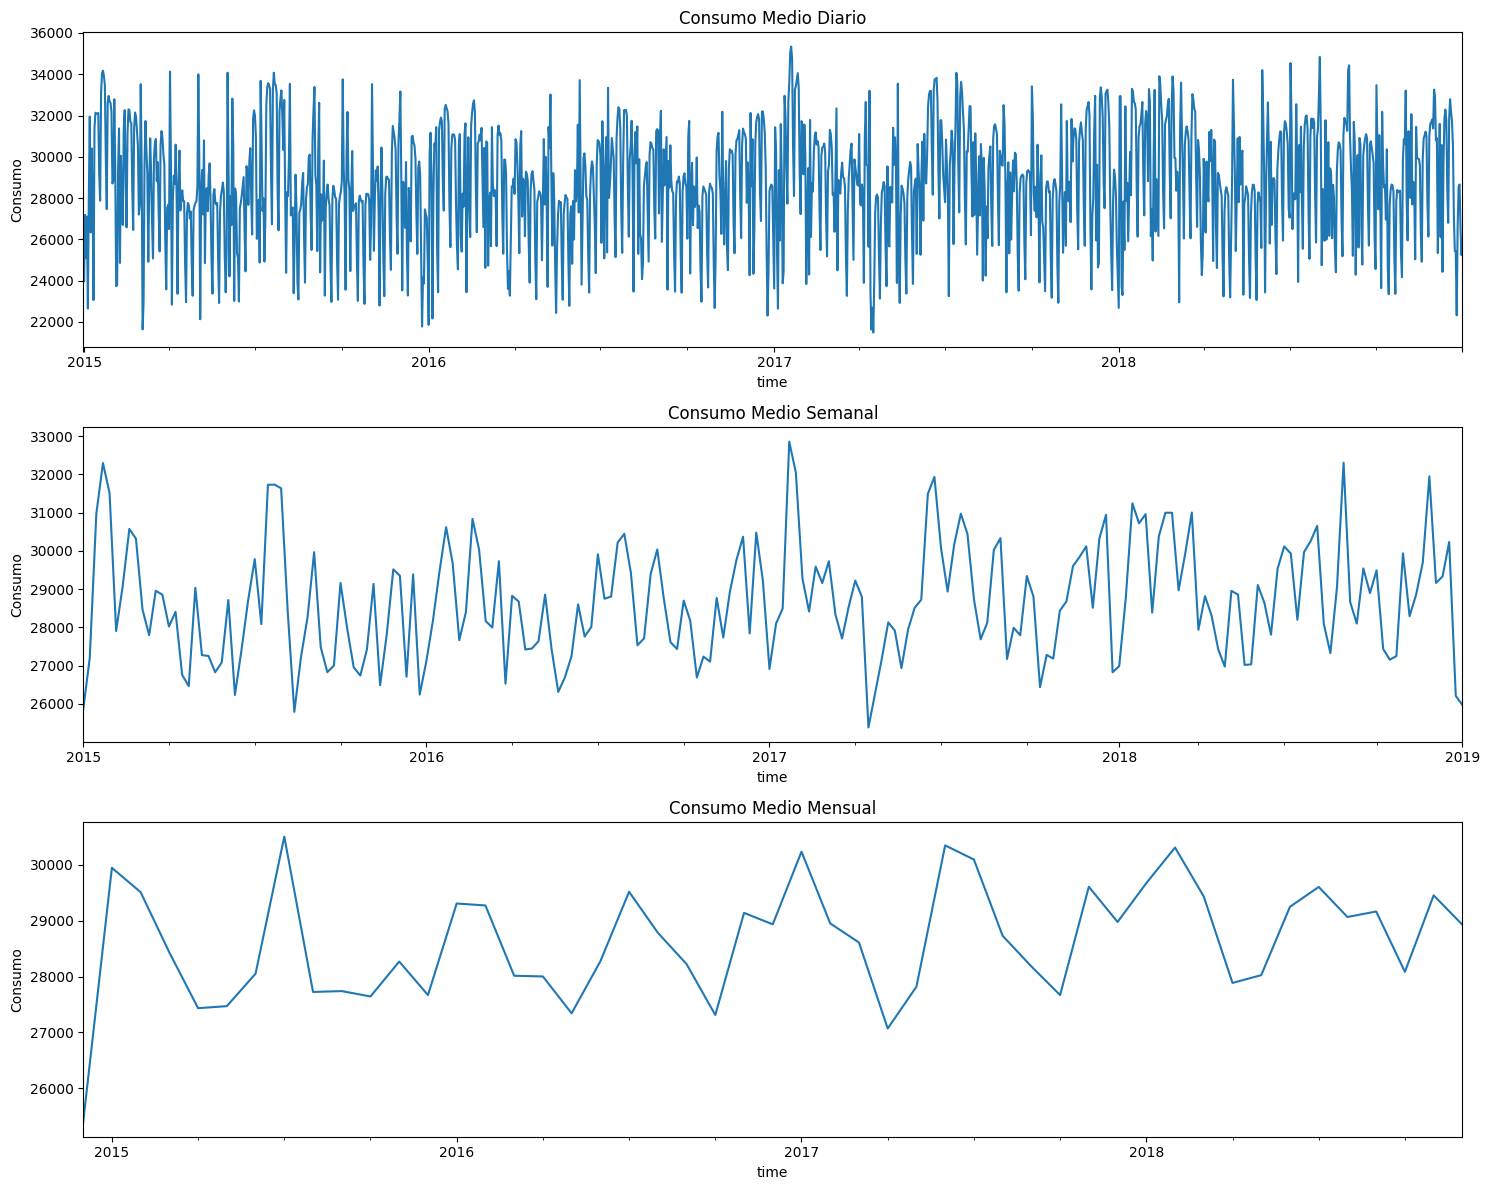

In [11]:
df_diario = df_clean['total load actual'].resample('D').mean()
df_semanal = df_clean['total load actual'].resample('W').mean()
df_mensual = df_clean['total load actual'].resample('M').mean()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))

df_diario.plot(ax=ax1, title='Consumo Medio Diario')
ax1.set_ylabel('Consumo')

df_semanal.plot(ax=ax2, title='Consumo Medio Semanal')
ax2.set_ylabel('Consumo')

df_mensual.plot(ax=ax3, title='Consumo Medio Mensual')
ax3.set_ylabel('Consumo')

plt.tight_layout()
plt.show()

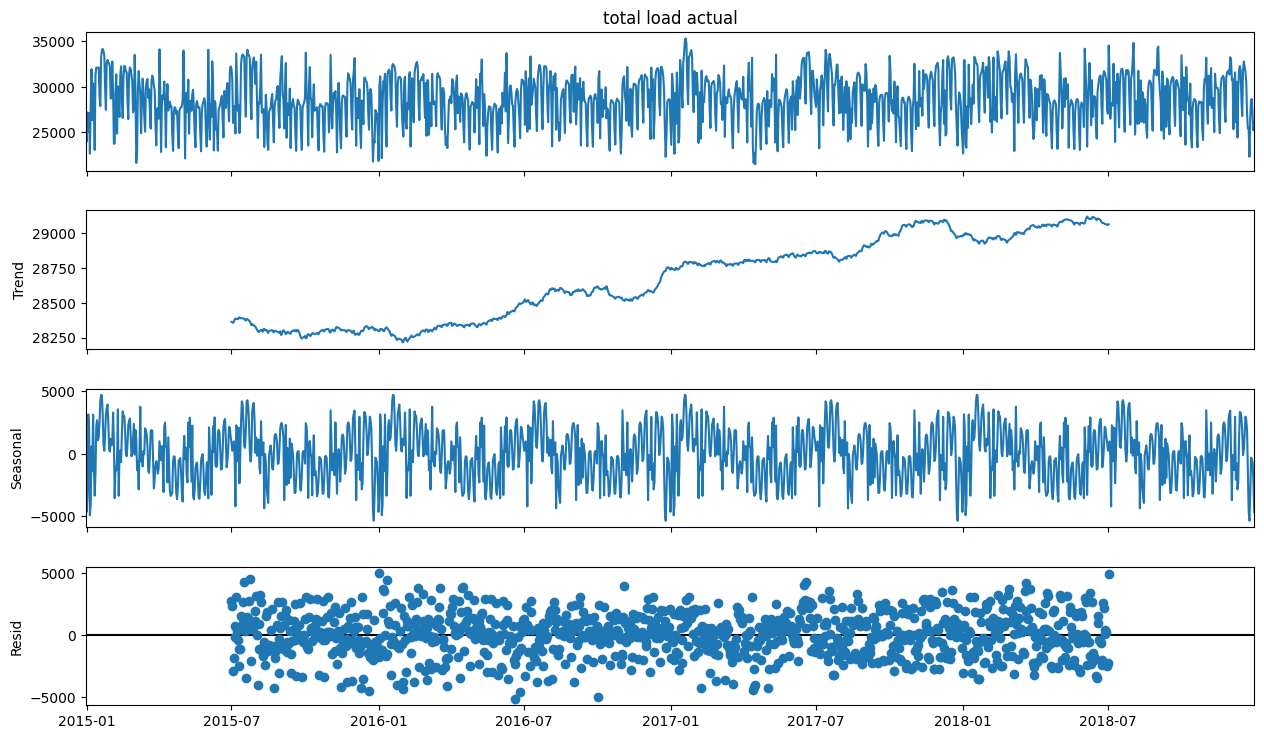

In [21]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

serie = df_clean['total load actual'].resample('D').mean()

decomposition = seasonal_decompose(serie, model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(14,8)
plt.show()

Hacemos un resample diario, ya que es el mejor para "limpiar" el ruido sin perder la esencia porque permite ver la estacionalidad semanal (el bajón de los sábados y domingos) y la anual. No se "borra" la realidad del día a día.

Vemos cómo afecta el cambio de estaciones (invierno, primavera, verano, otoño) al consumo diario.

Se ve una sola onda que sube en los meses fríos/calurosos y baja en los templados.

---

##  13. Test de Estacionariedad (ADF Test)



El **Test de Dickey-Fuller Aumentado (ADF)** determina si la serie es estacionaria.

**Estacionaria:** Media y varianza constantes en el tiempo → se puede modelar con ARIMA/SARIMA directamente

**No estacionaria:** Requiere **diferenciación** para estabilizar la media.

<Figure size 1200x500 with 0 Axes>

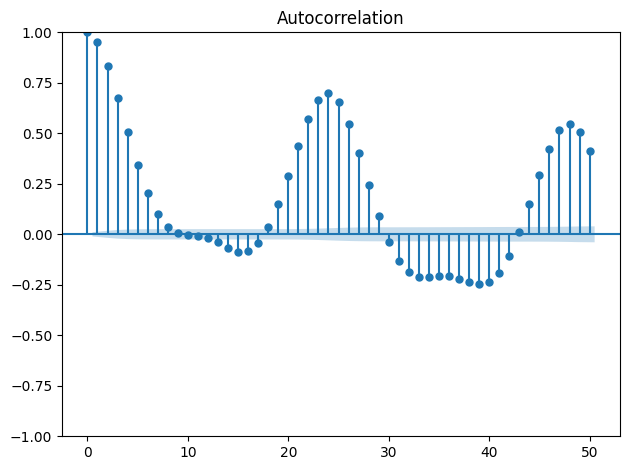

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

serie_energia = df['total load actual'].dropna()

plt.figure(figsize=(12,5))

# Graficamos los primeros 50 lags (unas 2 días de datos horarios)
plot_acf(serie_energia, lags=50)

plt.tight_layout()
plt.show()

El pico en el lag 24: Hay una correlación altísima (casi 0.75) con el dato de hace exactamente 24 horas. Esto es la definición de un ciclo diario.

El valle en el lag 12: El consumo a las 12 horas de diferencia suele ser lo opuesto (si a las 12:00 PM es máximo, a las 12:00 AM es mínimo).

Conclusión: La serie tiene una memoria larga y cíclica. Como no decae a cero rápidamente, confirma que aunque sea "estacionaria" según el ADF, tiene un componente estacional que no se puede ignorar.

<Figure size 1200x500 with 0 Axes>

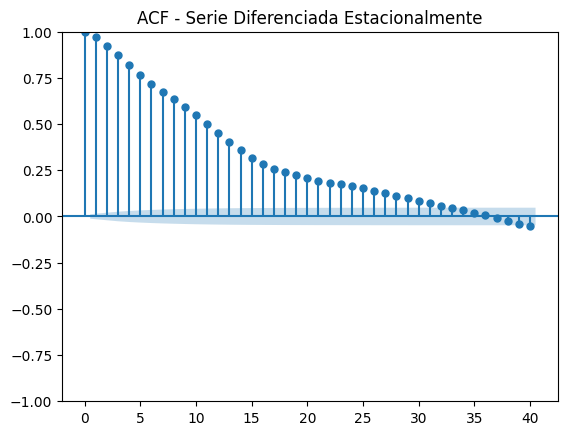

In [14]:
# Diferenciación estacional
df_clean['Diff_Seasonal'] = df_clean['total load actual'].diff(8760)

plt.figure(figsize=(12,5))
plot_acf(df_clean['Diff_Seasonal'].dropna(), lags=40)
plt.title("ACF - Serie Diferenciada Estacionalmente")
plt.show()

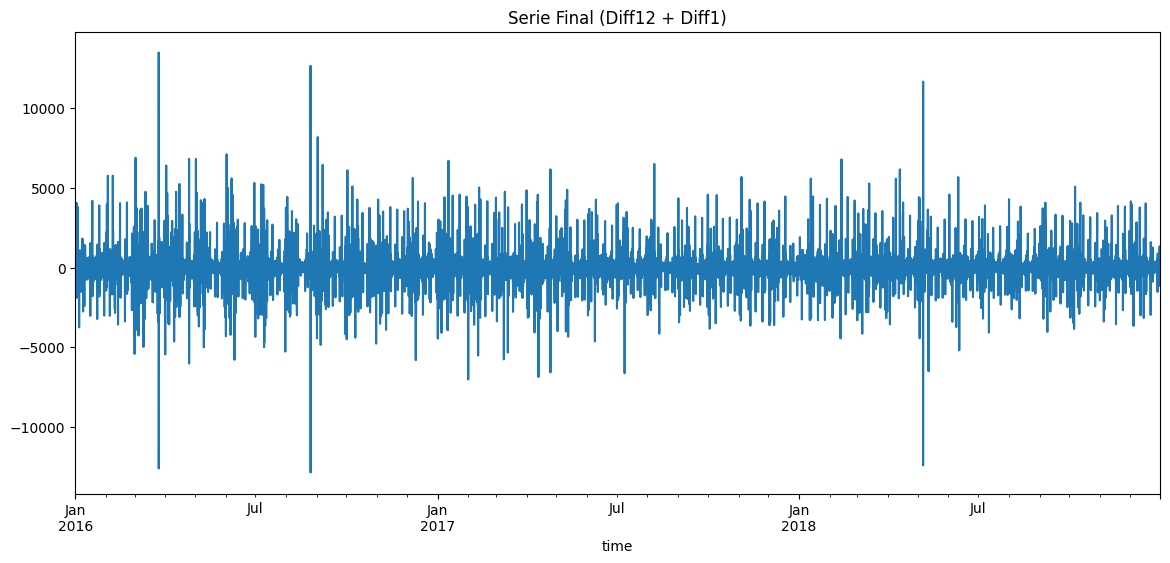

In [15]:
# Diferenciación simple
df_clean['Diff_Final'] = df_clean['Diff_Seasonal'].diff(1)

# Visualizar resultado final
plt.figure(figsize=(14,6))
df_clean['Diff_Final'].dropna().plot(title="Serie Final (Diff12 + Diff1)")
plt.show()

<Figure size 1200x500 with 0 Axes>

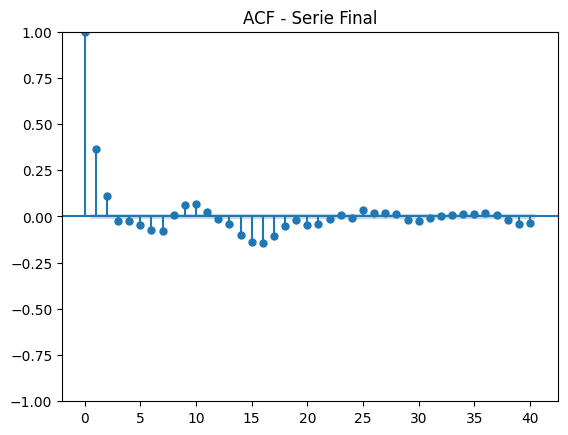

<Figure size 1200x500 with 0 Axes>

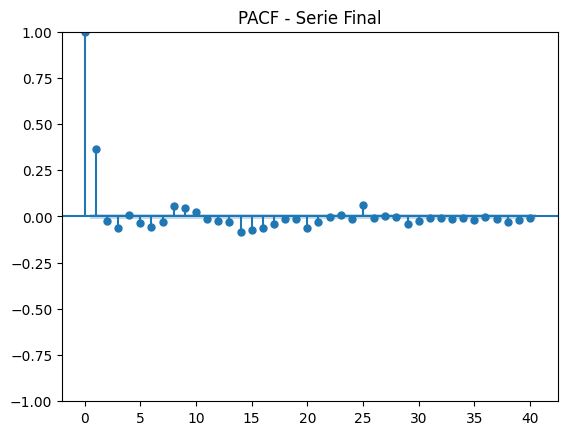

In [16]:
plt.figure(figsize=(12,5))
plot_acf(df_clean['Diff_Final'].dropna(), lags=40)
plt.title("ACF - Serie Final")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df_clean['Diff_Final'].dropna(), lags=40)
plt.title("PACF - Serie Final")
plt.show()

---

##   14. Análisis Técnico: Media Móvil y Golden Cross



Aplicamos técnicas de **análisis técnico** (usadas en finanzas) al **precio eléctrico**.

**Medias Móviles:**
- **MA_24**: Media móvil de 24 horas (corto plazo)
- **MA_168**: Media móvil de 168 horas (largo plazo / 1 semana)

**Golden Cross:** Cuando MA corto cruza por encima de MA largo → señal alcista (precios subiendo)

---

##   15. Análisis de Volatilidad



La **volatilidad** mide la variabilidad de los precios/demanda en el tiempo.

**Volatilidad = Rolling Standard Deviation**

Alta volatilidad → Mayor riesgo/incertidumbre en el mercado

---

##  16. Modelo SARIMA (Seasonal ARIMA)



**SARIMA(p,d,q)(P,D,Q,s)** modela series temporales con estacionalidad.

**Parámetros:**
- **(p,d,q)**: Componente no estacional (AR, diferenciación, MA)
- **(P,D,Q,s)**: Componente estacional con periodo s=24 (horas)

**Nota:** Entrenar SARIMA con todos los datos toma mucho tiempo. Usaremos una muestra para demostración.

In [17]:
import pmdarima as pm

auto_model = pm.auto_arima(
    df_clean['total load actual'],
    seasonal=False,   # buscar estacionalidad
    trace=True,      # muestra los modelos que prueba
    stepwise=True,   # búsqueda más rápida
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=578773.435, Time=28.51 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=608947.816, Time=0.55 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=584645.310, Time=1.50 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=590386.556, Time=8.19 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=608945.816, Time=0.30 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=583262.635, Time=7.31 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=578863.280, Time=15.94 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=578816.084, Time=18.50 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=578768.619, Time=27.81 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=583094.754, Time=7.22 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=578801.421, Time=28.00 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=577435.313, Time=34.28 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=21.89 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept   : AIC=inf, Time=48.68 sec
 ARIMA(2,1,

In [ ]:
import pmdarima as pm

auto_model = pm.auto_arima(
    df_clean['total load actual'],
    seasonal=True,   # buscar estacionalidad
    m=24,            # ciclo diario (24 horas)
    trace=True,      # muestra los modelos que prueba
    stepwise=True,   # búsqueda más rápida
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=146.08 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=608947.816, Time=0.32 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=567524.102, Time=32.01 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=578106.968, Time=37.63 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=608945.816, Time=0.38 sec
 ARIMA(1,1,0)(0,0,0)[24] intercept   : AIC=584645.310, Time=1.50 sec
 ARIMA(1,1,0)(2,0,0)[24] intercept   : AIC=inf, Time=231.41 sec
 ARIMA(1,1,0)(1,0,1)[24] intercept   : AIC=inf, Time=178.36 sec
 ARIMA(1,1,0)(0,0,1)[24] intercept   : AIC=574305.752, Time=36.27 sec
 ARIMA(1,1,0)(2,0,1)[24] intercept   : AIC=inf, Time=384.98 sec
 ARIMA(0,1,0)(1,0,0)[24] intercept   : AIC=inf, Time=26.09 sec
 ARIMA(2,1,0)(1,0,0)[24] intercept   : AIC=567522.654, Time=59.97 sec
 ARIMA(2,1,0)(0,0,0)[24] intercept   : AIC=583132.852, Time=2.07 sec


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(df_clean['total load actual'], order=(2,1,4))
result_arima = model_arima.fit()

print(result_arima.summary())

# Predicción 24 meses
forecast_arima = result_arima.forecast(steps=8760)

# Crear índice de fechas futuras
future_dates = pd.date_range(
    start=df_clean.index[-1] + pd.Timedelta(hours=1), # Empezamos una hora después del último dato
    periods=8760,
    freq='H' # La frecuencia es 'H' de hora, no 'MS' de mes
)

forecast_arima = pd.Series(forecast_arima.values, index=future_dates)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    df_clean['total load actual'],
    order=(0,1,1),
    seasonal_order=(2,1,0,24)
)

result_sarima = model_sarima.fit()

print(result_sarima.summary())

# Predicción 12 meses
forecast_sarima = result_sarima.forecast(steps=8760)

forecast_sarima = pd.Series(forecast_sarima.values, index=future_dates)

---

##  17. Preparación para Machine Learning



Preparamos el dataset con features engineered para modelos de Machine Learning.

**Importante:** División temporal (NO train_test_split aleatorio) para respetar el orden cronológico.

---

##  18. Modelo Random Forest



**Random Forest** es un ensemble de árboles de decisión que funciona muy bien para series temporales con features engineered.

**Ventaja:** Proporciona **feature importance** que nos permite identificar las variables más predictivas.

---

##   19. Modelo Gradient Boosting (LightGBM/XGBoost)



**Gradient Boosting** suele ser el modelo MÁS POTENTE para problemas de regresión y forecasting.

Usaremos **LightGBM** o **XGBoost** (dependiendo de disponibilidad).

---

##  20. Comparación Final de Modelos



Comparamos todos los modelos entrenados para determinar cuál es el mejor.

---

##  21. Visualizaciones Finales: Predicciones vs Valores Reales



Visualización de las predicciones de todos los modelos comparadas con los valores reales.

---

##   22. Conclusiones y Hallazgos Clave

###   Responsable: Todos
